In [35]:
import random
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import MACCSkeys
import torch_geometric.data as gd
from torch_geometric.loader import DataLoader
from gflownet.proxy.mol_utils import smiles2graph, random_split
from gflownet.utils.sqlite_log import read_all_results
from gflownet.utils.conditioning import TemperatureConditional
from gflownet.models.graph_transformer import GraphTransformerGFN
from gflownet.algo.trajectory_balance import TrajectoryBalance
from gflownet.algo.flow_matching import FlowMatching
from gflownet.envs.graph_building_env import GraphBuildingEnv
from gflownet.envs.frag_mol_env import FragMolBuildingEnvContext
from gflownet.models import bengio2021flow
from utils import obtain_run, load_proxy_sol,  create_dir, scale_rew, infer_model
from scipy.stats import pearsonr, spearmanr
from gflownet.models.bengio2021flow import FRAGMENTS

In [157]:
id = "fm_experiment(lr=5e-4)"
current_dir = Path().resolve().parent
proxy_model = load_proxy_sol()
proxy_model.eval()
yaml_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "config.yaml"
model_dir = current_dir / "src" / "gflownet" / "tasks" / "logs" / id / "model_state.pt"
cfg = OmegaConf.load(yaml_dir)
# Load env
env = GraphBuildingEnv()
temp_cond = TemperatureConditional(cfg)
num_cond_dim = temp_cond.encoding_size()
ctx = FragMolBuildingEnvContext(
max_frags=cfg.algo.max_nodes,
num_cond_dim=num_cond_dim,
fragments=bengio2021flow.FRAGMENTS,
)
# Load GFN Model
model = GraphTransformerGFN(
env_ctx=ctx,
cfg=cfg,
num_graph_out=cfg.algo.tb.do_predict_n + 1,
do_bck=cfg.algo.tb.do_parameterize_p_b,
)
model.load_state_dict((torch.load(model_dir)["models_state_dict"][0]))
model.eval()
# Load Algo
algo = FlowMatching(env, ctx, cfg)
# Load cond_info
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
num_gen = 100
total_rew = []
total_policy = []
cond_info = temp_cond.sample(num_gen)["encoding"]
total_smiles = []
total_trajs = []
for _ in range(50):
    samples = algo.create_training_data_from_own_samples(model=model, n=num_gen, cond_info=cond_info)
    trajectories = [sample["traj"] for sample in samples]
    rdkit_mols = [ctx.graph_to_obj(traj[-1][0]) for traj in trajectories]
    smiles = [Chem.MolToSmiles(mol) for mol in rdkit_mols]
    # Get preds
    graphs = [smiles2graph(Chem.MolFromSmiles(smile)) for smile in smiles]
    batch = gd.Batch.from_data_list([g for g in graphs if g is not None])
    preds = (
        proxy_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch).squeeze(dim=-1).cpu().detach().numpy()
    )
    total_smiles.extend(smiles)
    total_trajs.extend(trajectories)

In [174]:
def get_init_frag(total_trajs, id):
    smiles_frags = []
    for traj in total_trajs:
        last_state = traj[-1]
        frags_idx = [tr[1]['v'] for tr in last_state[0].nodes(data=True)]
        if frags_idx[0] == id:
            smile_frag = [fr[0] for i, fr in enumerate(FRAGMENTS) if i in frags_idx]
            smile_frag = [FRAGMENTS[i][0] for i in frags_idx]
            smiles_frags.append(smile_frag) 
    return smiles_frags

In [191]:
nh3 = get_init_frag(total_trajs, 28) # get 1, -1, 
cnc0 = get_init_frag(total_trajs, 24) # get -2
ccno = get_init_frag(total_trajs, 18) # 2 , -3

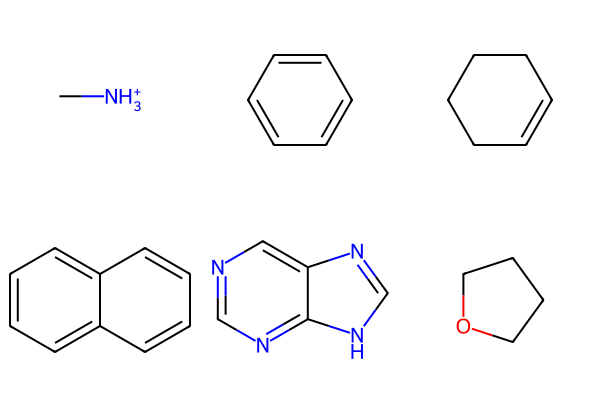

In [193]:
from rdkit.Chem import Draw

# Generate molecule objects from SMILES
mols = [Chem.MolFromSmiles(smile) for smile in nh3[-1]]

# Visualize the molecules
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(200, 200))

In [196]:
nh3

[['C[NH3+]', 'c1cncnc1', 'C1CCCCC1', 'C=C', 'C1CCOCC1', 'O=[SH](=O)O'],
 ['C[NH3+]', 'c1ccccc1', 'C1CCCCC1', 'c1ccccc1', 'C1CCCCC1', 'CC(C)O'],
 ['C[NH3+]', 'c1ccncc1', 'C=CC', 'C1CCCCC1', 'c1ccccc1', 'FC(F)F'],
 ['C[NH3+]', 'c1ccccc1', 'c1ccccc1', 'c1ccccc1', 'c1ccncc1', 'c1ccccc1'],
 ['C[NH3+]', 'C1CCCCC1', 'C1CCCCC1', 'C1CCCCC1', 'C1CCNCC1', 'C'],
 ['C[NH3+]', 'C1CCCCC1', 'c1ncc2nc[nH]c2n1', 'c1ccccc1', 'C1CCCCC1', 'I'],
 ['C[NH3+]', 'c1ccccc1', 'c1ccncc1', 'C1CCCCC1', 'C1CCNCC1', 'CNC=O'],
 ['C[NH3+]',
  'c1ccccc1',
  'C1=CCCCC1',
  'c1ccc2ccccc2c1',
  'c1ncc2nc[nH]c2n1',
  'C1CCOC1']]

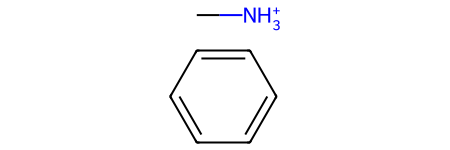

In [ ]:
from rdkit import Chem
mols = [Chem.MolFromSmiles(smile) for smile in nh3[-1]]
Chem.CombineMols(mols[0], mols[1])

In [ ]:
mols

In [194]:
one_traj

(<[0, 1, 2, 3, 4, 5], [(0, 1), (0, 3), (1, 2), (2, 4), (4, 5)], [47, 46, 6, 29, 46, 39]>,
 <GraphActionType.Stop, >)

In [75]:
# Get nodes
frags = [tr[1]['v'] for tr in one_traj[0].nodes(data=True)]

In [76]:
frags

[47, 46, 6, 29, 46, 39]

In [70]:
one_traj[0]

<[0, 1, 2, 3, 4, 5], [(0, 1), (0, 3), (1, 2), (2, 4), (4, 5)], [47, 46, 6, 29, 46, 39]>

In [74]:
for tr in one_traj[0].nodes(data=True):
    print(tr[1])

{'v': 47}
{'v': 46}
{'v': 6}
{'v': 29}
{'v': 46}
{'v': 39}
